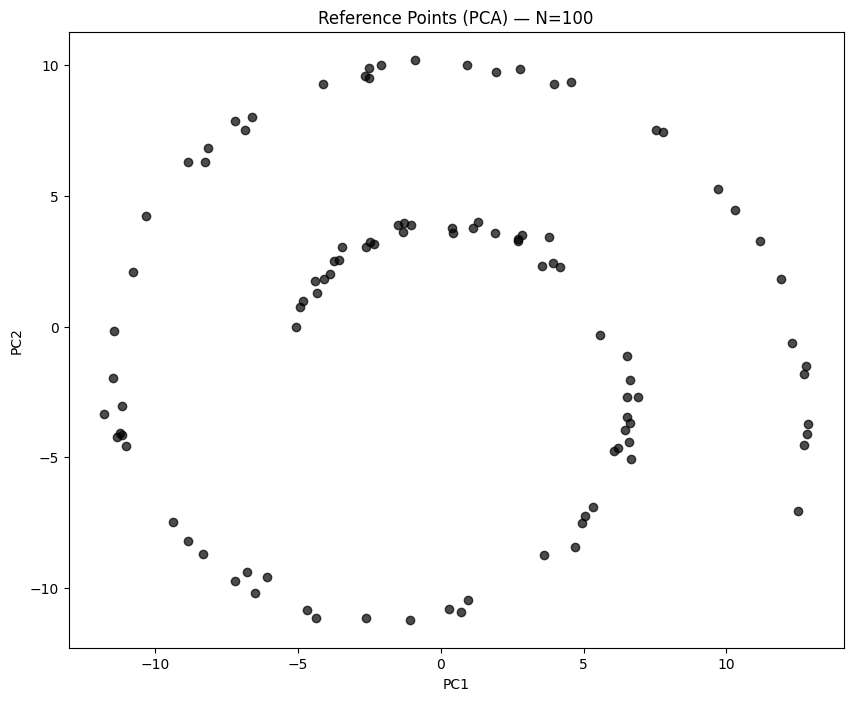

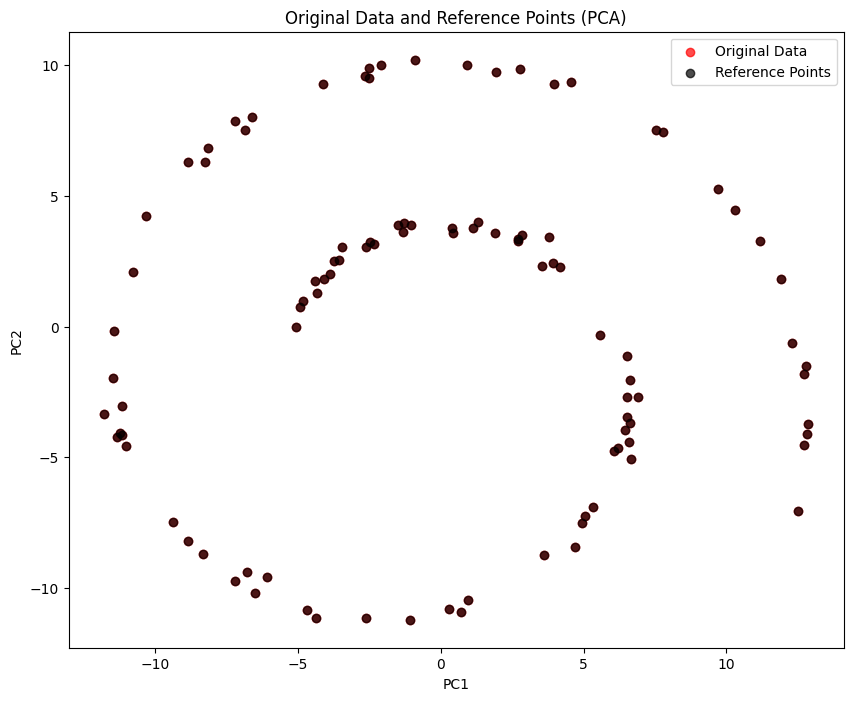

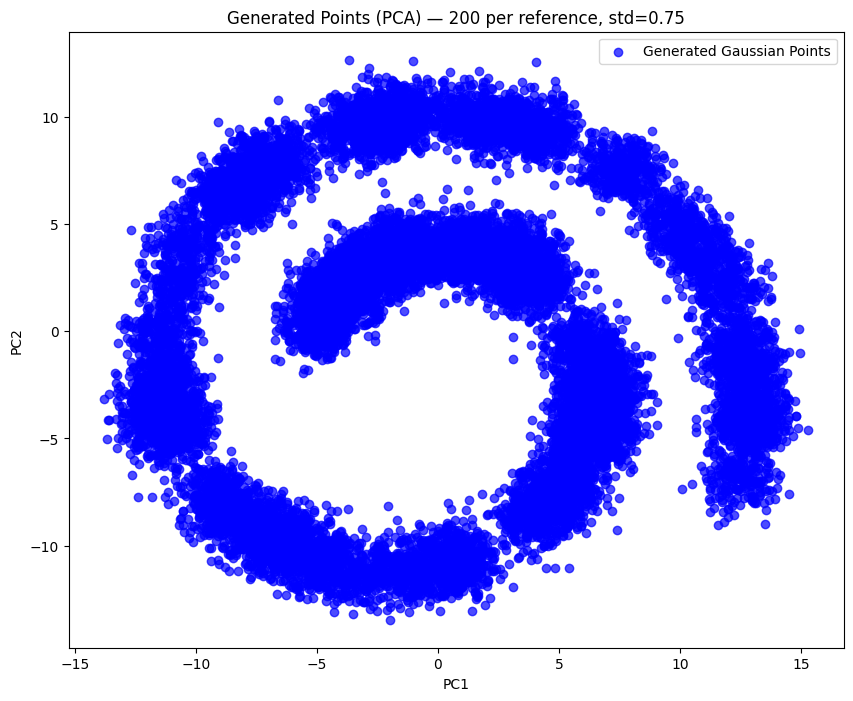

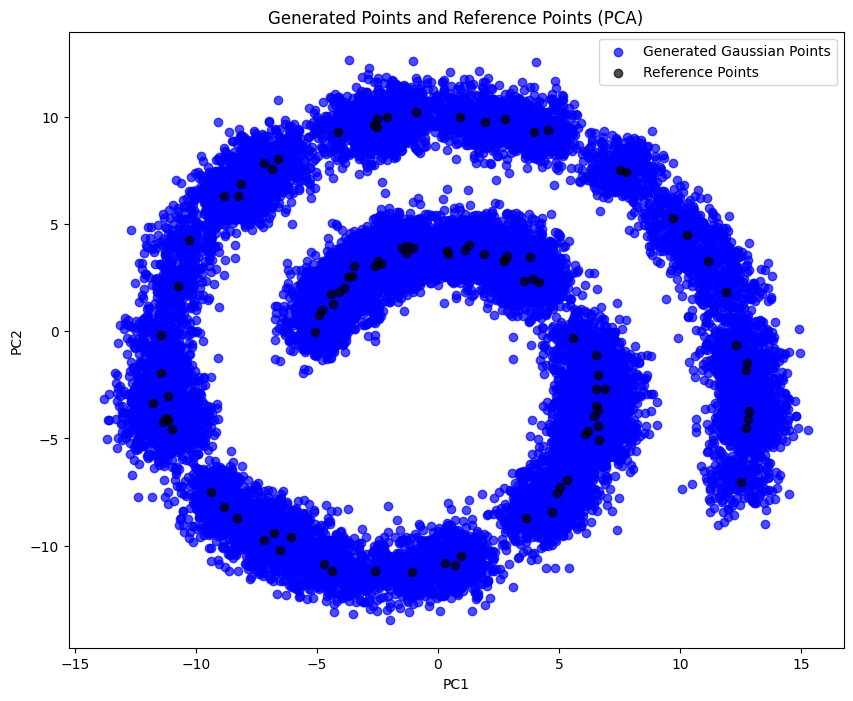

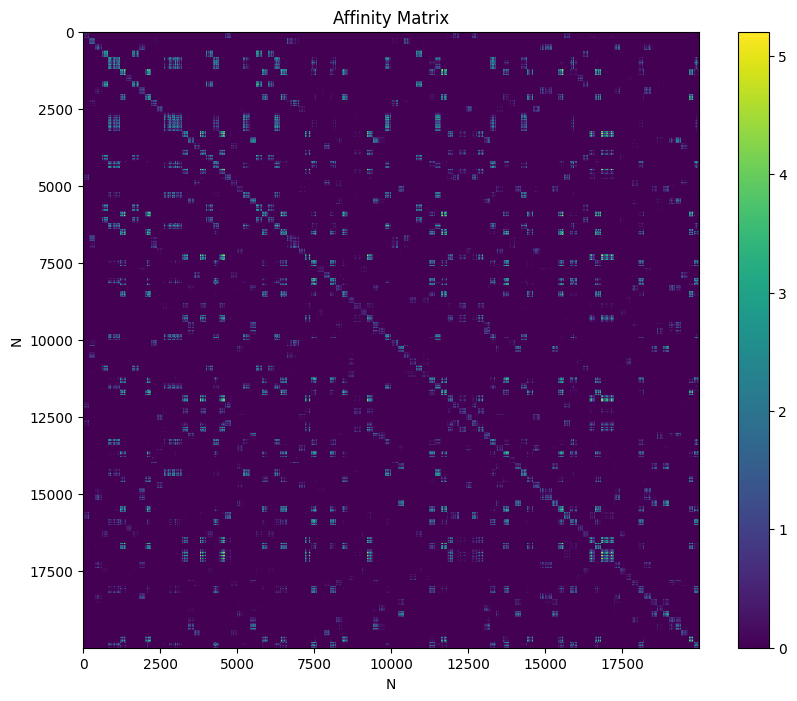

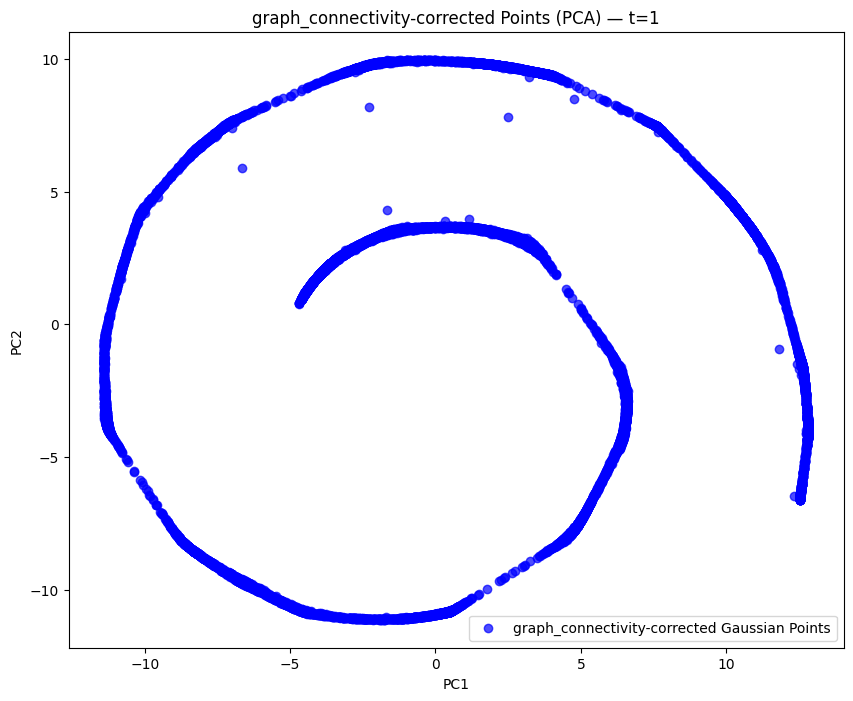

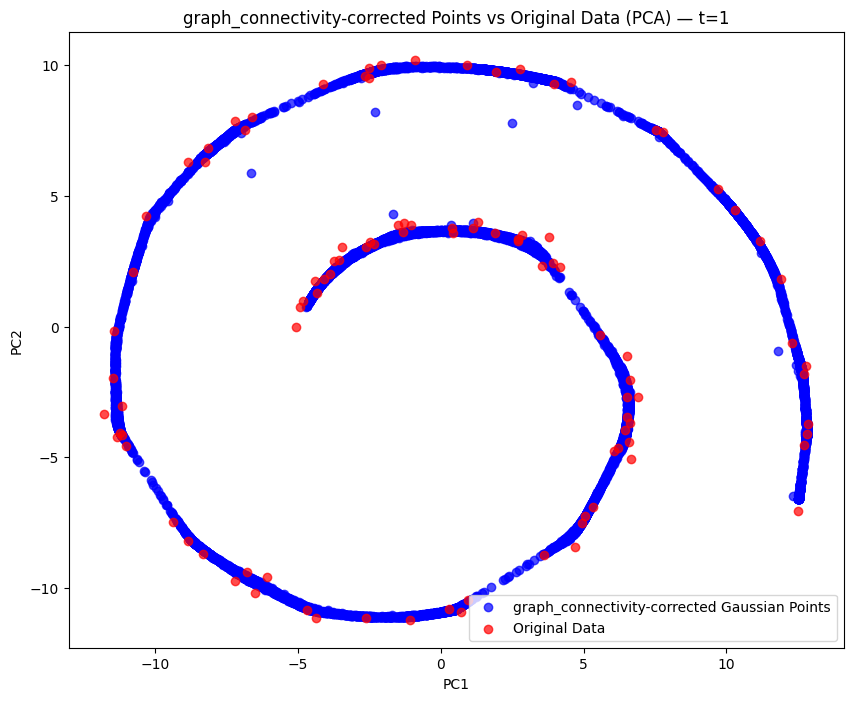

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_swiss_roll
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

def build_affinity_matrix(O, N, sigma=1.0):
    dist_NO = pairwise_distances(N, O, squared=True)
    dist_ON = dist_NO.T
    K_NO = np.exp(-dist_NO / (2 * sigma**2))
    K_ON = np.exp(-dist_ON / (2 * sigma**2))
    K_NN = K_NO @ K_ON
    return K_NN

def sort_swiss(data, label):
    distances = np.linalg.norm(data, axis=1)
    sorted_idx = np.argsort(distances)
    return data[sorted_idx], label[sorted_idx]

def reference_selection(data, n_clusters, random_state):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    kmeans.fit(data)
    return kmeans.cluster_centers_

def generate_gaussian(data, num_gauss_points, std=0.5):
    gaussian_points = []
    for point in data:
        points = np.random.normal(loc=point, scale=std, size=(num_gauss_points, len(point)))
        gaussian_points.append(points)
    return np.vstack(gaussian_points)

def graph_connectivity(O, N, K_NN, t):
    D = np.diag(np.sum(K_NN, axis=1))
    P_NN = np.linalg.inv(D) @ K_NN
    P_NN_powered = np.linalg.matrix_power(P_NN, t)
    N_graph_connectivity = P_NN_powered @ N
    all_points = np.vstack([O, N_graph_connectivity])
    return N_graph_connectivity, all_points

def pca_plot(data, c, label=None):
    proj = pca.transform(data)
    plt.scatter(proj[:, 0], proj[:, 1], c=c, label=label, alpha=0.7)

def pca_axis_labels():
    plt.xlabel('PC1')
    plt.ylabel('PC2')

num_data_points = 100
noise = 0.2
random_state = 42
n_clusters = 25
num_gauss_points = 500
std_list = [0.75]
num_points_list = [200]

original_data, color = make_swiss_roll(n_samples=num_data_points, noise=noise, random_state=random_state)

pca = PCA(n_components=2)
original_data[:, 1] *= 0.01
pca.fit(original_data)

reference_points = original_data


fig = plt.figure(figsize=(10, 8))
pca_plot(reference_points, c='black')
plt.title(f'Reference Points (PCA) — N={len(reference_points)}')
pca_axis_labels()
plt.show()

fig = plt.figure(figsize=(10, 8))
pca_plot(original_data, c='red', label='Original Data')
pca_plot(reference_points, c='black', label='Reference Points')
plt.title('Original Data and Reference Points (PCA)')
pca_axis_labels()
plt.legend()
plt.show()

for std in std_list:
    for num_gauss_points in num_points_list:

        generated_points = generate_gaussian(reference_points, num_gauss_points, std)

        
        fig = plt.figure(figsize=(10, 8))
        pca_plot(generated_points, c='blue', label='Generated Gaussian Points')
        plt.title(f'Generated Points (PCA) — {num_gauss_points} per reference, std={std}')
        pca_axis_labels()
        plt.legend()
        plt.show()


        fig = plt.figure(figsize=(10, 8))
        pca_plot(generated_points, c='blue', label='Generated Gaussian Points')
        pca_plot(reference_points, c='black', label='Reference Points')
        plt.title('Generated Points and Reference Points (PCA)')
        pca_axis_labels()
        plt.legend()
        plt.show()

        affinity_matrix_NN = build_affinity_matrix(O=original_data, N=generated_points, sigma=1.0)


        plt.figure(figsize=(10, 8))
        plt.imshow(affinity_matrix_NN, cmap='viridis', interpolation='nearest')
        plt.colorbar()
        plt.title('Affinity Matrix')
        plt.xlabel('N')
        plt.ylabel('N')
        plt.show()

        t_list = [1]

        for t in t_list:
            N_graph_connectivity, all_points = graph_connectivity(original_data, generated_points, affinity_matrix_NN, t)

            # Plot 7: graph_connectivity-corrected points
            fig = plt.figure(figsize=(10, 8))
            pca_plot(N_graph_connectivity, c='blue', label='graph_connectivity-corrected Gaussian Points')
            plt.title(f'graph_connectivity-corrected Points (PCA) — t={t}')
            pca_axis_labels()
            plt.legend()
            plt.show()

            # Plot 8: graph_connectivity-corrected + original data
            fig = plt.figure(figsize=(10, 8))
            pca_plot(N_graph_connectivity, c='blue', label='graph_connectivity-corrected Gaussian Points')
            pca_plot(original_data, c='red', label='Original Data')
            plt.title(f'graph_connectivity-corrected Points vs Original Data (PCA) — t={t}')
            pca_axis_labels()
            plt.legend()
            plt.show()